# Temporal Centralities and SIR Model

In [1]:
print("="*80)
print("IMPORTING LIBRARIES AND MODULES")
print("="*80)

import networkx as nx
from src.Plots import *
from src.Simulations import *
from src.Metrics import *

IMPORTING LIBRARIES AND MODULES


In [2]:
print("="*80)
print("DEFINING PARAMETERS FOR THE SIMULATIONS")
print("="*80)

N = 400
m = 4
steps = 50
beta = 0.13
gamma = 0.08
w = 0.3
p_rand = 0
gamma_val = 0.1

DEFINING PARAMETERS FOR THE SIMULATIONS


### Development of a Rewiring Model

RUNNING TOY SIMULATION OF THE REWIRING MODEL
This simulation is only for visualization purposes. Might not reflect the average behavior over multiple runs.
Since the run is stochastic, results will vary at each execution, so might happen that no significant spreading occurs.
--------------------------------------------------------------------------------


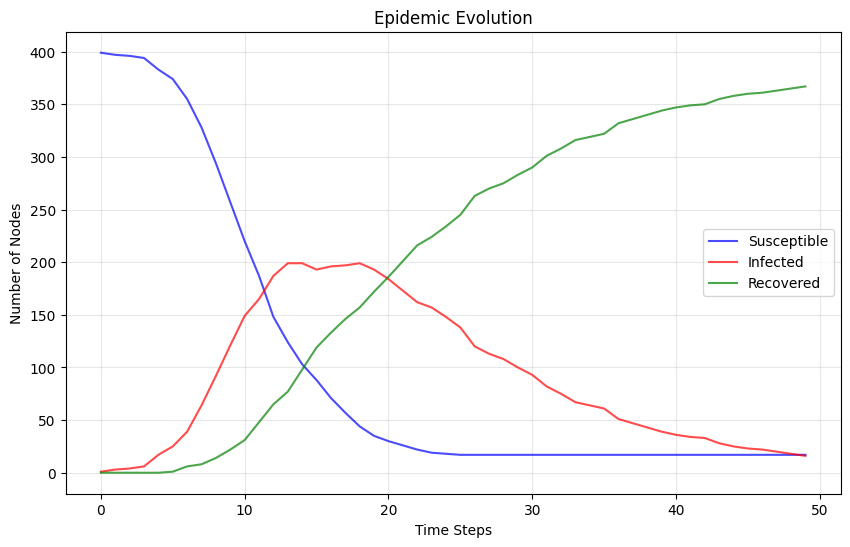

In [3]:
print("="*80)
print("RUNNING TOY SIMULATION OF THE REWIRING MODEL")
print("="*80)
print("This simulation is only for visualization purposes. Might not reflect the average behavior over multiple runs.")
print("Since the run is stochastic, results will vary at each execution, so might happen that no significant spreading occurs.")
print("-"*80)
G = nx.barabasi_albert_graph(N, m)

pos_base = nx.spring_layout(G, seed=42)

for n in G:
    G.nodes[n]["state"] = "S"

seed_node = random.choice(list(G.nodes()))
G.nodes[seed_node]["state"] = "I"

history = simulate_SIR(G, beta=beta, gamma=gamma, w=w, max_steps=steps, p_rand=p_rand, stop_on_extinction=False)
plot_evolution(history)

### H1 and H2 Testing

COMPARING FOR A SUBSET OF NODES THE METRICS WITH DIFFERENT WINDOW SIZES
The comparison is based on the previous simulation run. Different runs will produce different results.
The scope of this comparison is to show how the choice of the window size affects the metrics computed.
--------------------------------------------------------------------------------
Analyzing Nodes: [82, 25, 254, 158, 199, 181, 192, 316]
Displaying Time Series for Windows: [5, 10, 15, 20, 25]


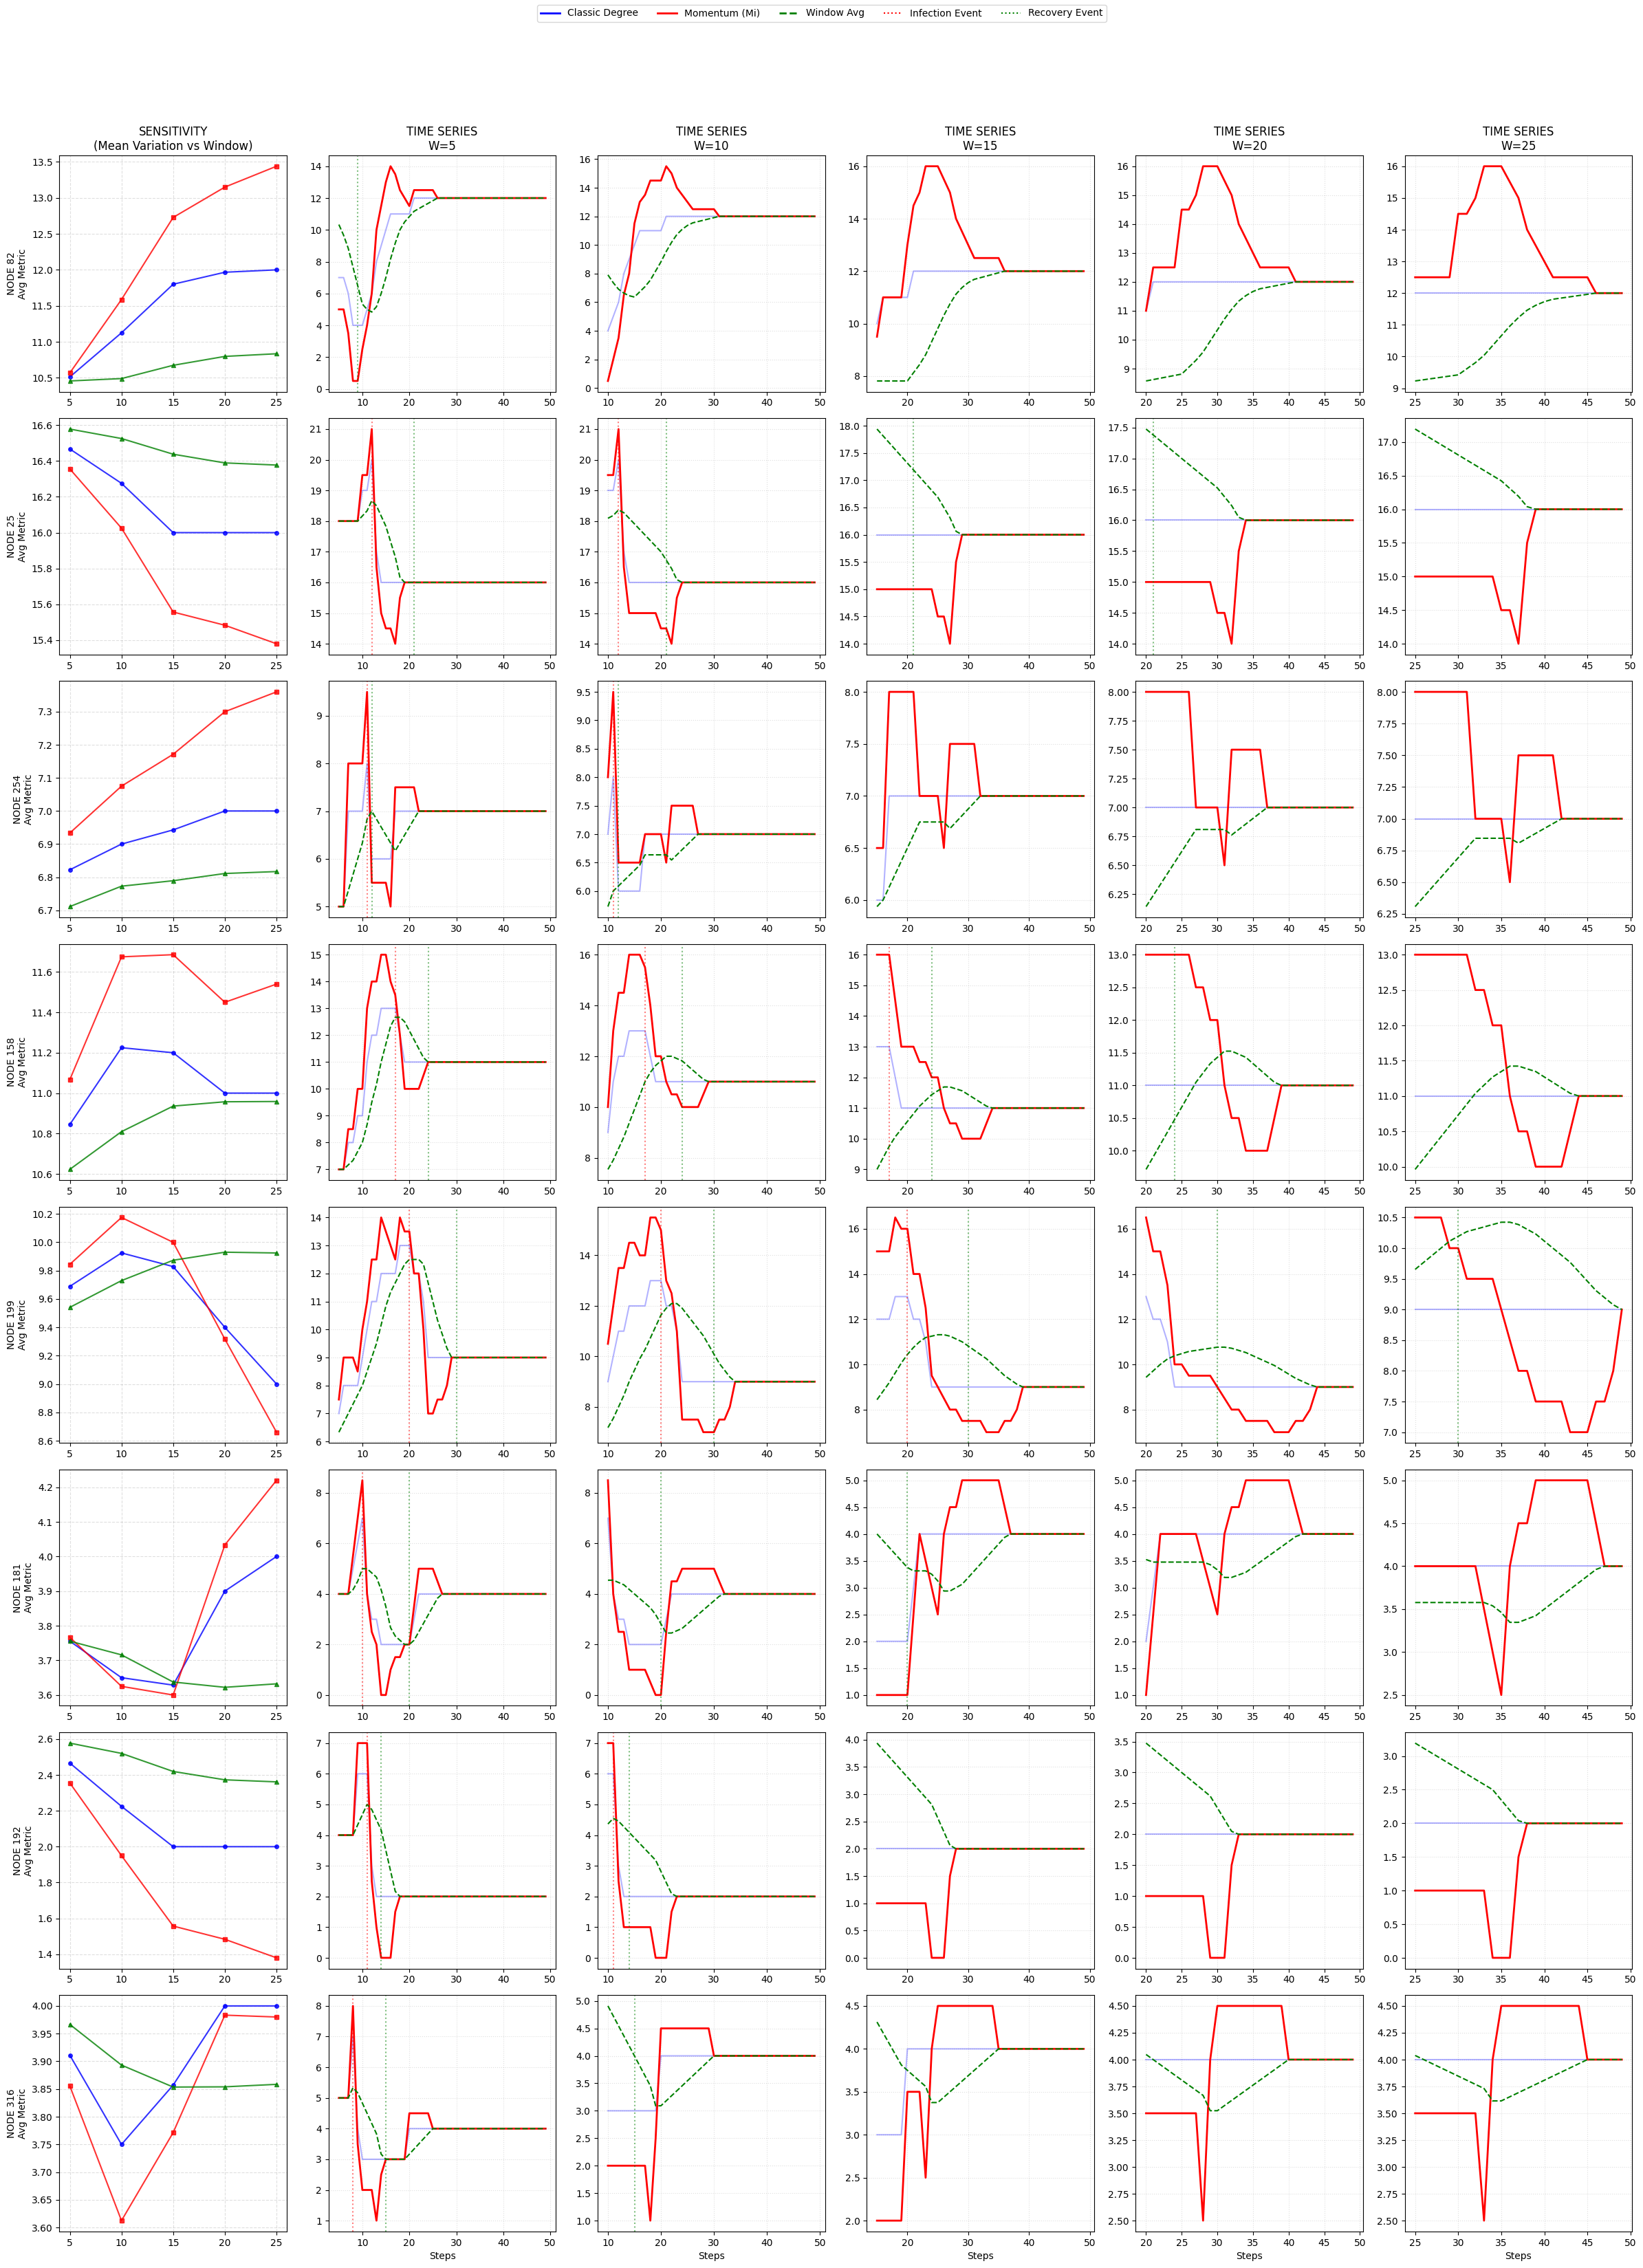

In [4]:
print("="*80)
print("COMPARING FOR A SUBSET OF NODES THE METRICS WITH DIFFERENT WINDOW SIZES")
print("="*80)
print("The comparison is based on the previous simulation run. Different runs will produce different results.")
print("The scope of this comparison is to show how the choice of the window size affects the metrics computed.")
print("-"*80)

selected_nodes = random.sample(range(N), 8)
plot_full_comparison_row(history, selected_nodes, max_window_size=len(history)//2)

### H3,H4 and H6 Testing

MONTE CARLO SIMULATIONS TO COMPARE EPIDEMIC SPREADING UNDER REWIRING AGAINST A STATIC NETWORK
=== PHASE 1: Generating Epidemic Threshold Plot ===
Processing ratio 0.00...
Processing ratio 0.69...
Processing ratio 1.38...
Processing ratio 2.07...
Processing ratio 2.76...
Processing ratio 3.45...


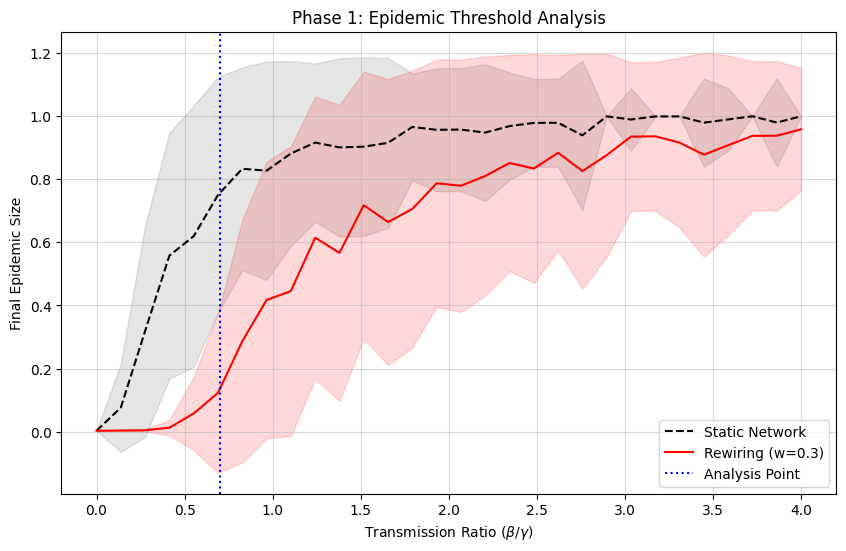


=== PHASE 2: Targeted Analysis at Ratio 0.70 ===

=== PHASE 3: Statistical Analysis ===

-- Spearman Correlation Analysis for Window 3 --


#### Spearman Correlations (Within-Node) - Window 3

,Start_Degree,ρ_Momentum,p_Momentum,ρ_AvgDeg,p_AvgDeg,ρ_DegPeak,p_DegPeak,N_Sims
Node,,,,,,,,
1,50,-0.200*,0.0457,-0.298**,0.0026,-0.260**,0.0091,100
2,49,-0.040,0.6914,-0.367***,0.0002,-0.157,0.1176,100
4,34,-0.116,0.2498,-0.396***,0.0000,-0.253*,0.0110,100
5,40,0.259**,0.0093,-0.343***,0.0005,0.028,0.7786,100
6,32,-0.028,0.7807,-0.440***,0.0000,-0.132,0.1914,100
7,36,-0.037,0.7140,-0.387***,0.0001,-0.154,0.1265,100
8,24,-0.066,0.5120,-0.569***,0.0000,-0.244*,0.0145,100
9,36,-0.146,0.1463,-0.646***,0.0000,-0.329***,0.0008,100
11,62,0.013,0.8959,-0.265**,0.0076,-0.142,0.1602,100



=== META-ANALYSIS ACROSS 32 NODES ===


,Metric,Mean ρ,Std ρ,Median ρ,N_nodes
0,Momentum,-0.325590,0.306716,-0.203579,32
1,Avg Degree,-0.645316,0.192535,-0.668827,32
2,Deg at Peak,-0.369964,0.171615,-0.349887,32


...

,Start Deg,Final Size,Peak Time,Peak < Window Count,Mean Deg at Peak,Mean Momentum,Mean Avg Deg
Seed Node,,,,,,,
1,50,0.56 ± 0.02,22.00 ± 1.01,4,15.01 ± 0.93,12.93 ± 0.90,16.94 ± 0.90
2,49,0.50 ± 0.03,20.36 ± 1.12,10,18.11 ± 1.15,15.49 ± 1.13,20.45 ± 1.09
4,34,0.50 ± 0.03,20.61 ± 1.33,13,12.49 ± 0.78,10.07 ± 0.77,13.68 ± 0.79
5,40,0.50 ± 0.03,21.31 ± 1.38,4,12.86 ± 0.75,9.94 ± 0.76,14.67 ± 0.71
6,32,0.46 ± 0.03,20.78 ± 1.40,12,13.05 ± 0.81,10.77 ± 0.85,13.99 ± 0.76
7,36,0.50 ± 0.03,19.29 ± 0.98,10,13.95 ± 0.81,11.58 ± 0.81,15.21 ± 0.76
8,24,0.41 ± 0.03,18.46 ± 1.35,17,10.00 ± 0.53,7.72 ± 0.54,10.91 ± 0.55
9,36,0.41 ± 0.03,18.73 ± 1.48,15,14.09 ± 0.91,11.41 ± 0.96,16.12 ± 0.88
11,62,0.54 ± 0.03,22.15 ± 1.10,4,20.00 ± 1.30,16.95 ± 1.31,22.78 ± 1.26


#### Table for Window 6

,Start Deg,Final Size,Peak Time,Peak < Window Count,Mean Deg at Peak,Mean Momentum,Mean Avg Deg
Seed Node,,,,,,,
1,50,0.56 ± 0.02,22.00 ± 1.01,7,15.01 ± 0.93,11.71 ± 0.93,16.48 ± 0.93
2,49,0.50 ± 0.03,20.36 ± 1.12,16,18.11 ± 1.15,14.56 ± 1.18,20.12 ± 1.13
4,34,0.50 ± 0.03,20.61 ± 1.33,17,12.49 ± 0.78,9.64 ± 0.80,13.36 ± 0.81
5,40,0.50 ± 0.03,21.31 ± 1.38,12,12.86 ± 0.75,9.08 ± 0.79,14.39 ± 0.74
6,32,0.46 ± 0.03,20.78 ± 1.40,18,13.05 ± 0.81,10.36 ± 0.89,13.79 ± 0.78
7,36,0.50 ± 0.03,19.29 ± 0.98,11,13.95 ± 0.81,10.91 ± 0.87,14.93 ± 0.78
8,24,0.41 ± 0.03,18.46 ± 1.35,26,10.00 ± 0.53,7.25 ± 0.57,10.80 ± 0.56
9,36,0.41 ± 0.03,18.73 ± 1.48,25,14.09 ± 0.91,10.62 ± 1.01,16.03 ± 0.91
11,62,0.54 ± 0.03,22.15 ± 1.10,11,20.00 ± 1.30,15.74 ± 1.37,22.24 ± 1.30


#### Table for Window 9

,Start Deg,Final Size,Peak Time,Peak < Window Count,Mean Deg at Peak,Mean Momentum,Mean Avg Deg
Seed Node,,,,,,,
1,50,0.56 ± 0.02,22.00 ± 1.01,10,15.01 ± 0.93,10.94 ± 0.95,16.43 ± 0.95
2,49,0.50 ± 0.03,20.36 ± 1.12,20,18.11 ± 1.15,14.29 ± 1.21,20.00 ± 1.14
4,34,0.50 ± 0.03,20.61 ± 1.33,19,12.49 ± 0.78,9.50 ± 0.83,13.27 ± 0.82
5,40,0.50 ± 0.03,21.31 ± 1.38,18,12.86 ± 0.75,8.77 ± 0.81,14.36 ± 0.75
6,32,0.46 ± 0.03,20.78 ± 1.40,24,13.05 ± 0.81,10.15 ± 0.90,13.81 ± 0.78
7,36,0.50 ± 0.03,19.29 ± 0.98,17,13.95 ± 0.81,10.73 ± 0.89,14.90 ± 0.79
8,24,0.41 ± 0.03,18.46 ± 1.35,33,10.00 ± 0.53,7.14 ± 0.59,10.77 ± 0.57
9,36,0.41 ± 0.03,18.73 ± 1.48,34,14.09 ± 0.91,10.43 ± 1.02,16.01 ± 0.91
11,62,0.54 ± 0.03,22.15 ± 1.10,12,20.00 ± 1.30,15.26 ± 1.40,22.12 ± 1.31


In [5]:
print("="*80)
print("MONTE CARLO SIMULATIONS TO COMPARE EPIDEMIC SPREADING UNDER REWIRING AGAINST A STATIC NETWORK")
print("="*80)

G_base = nx.barabasi_albert_graph(N, m)

tables = run_targeted_analysis(
    G_base, 
    gamma=gamma_val, 
    w=w, 
    p_rand=p_rand, 
    max_steps=2000,
    num_ratios=30,      
    num_sims=100,        
    analysis_ratio=0.7, 
    windows=[3,6,9]
)

### H5 Testing

MONTE CARLO SIMULATIONS TO COMPARE Rt METRIC UNDER REWIRING AGAINST A STATIC NETWORK
Running 100 parallel simulations for Rt analysis...


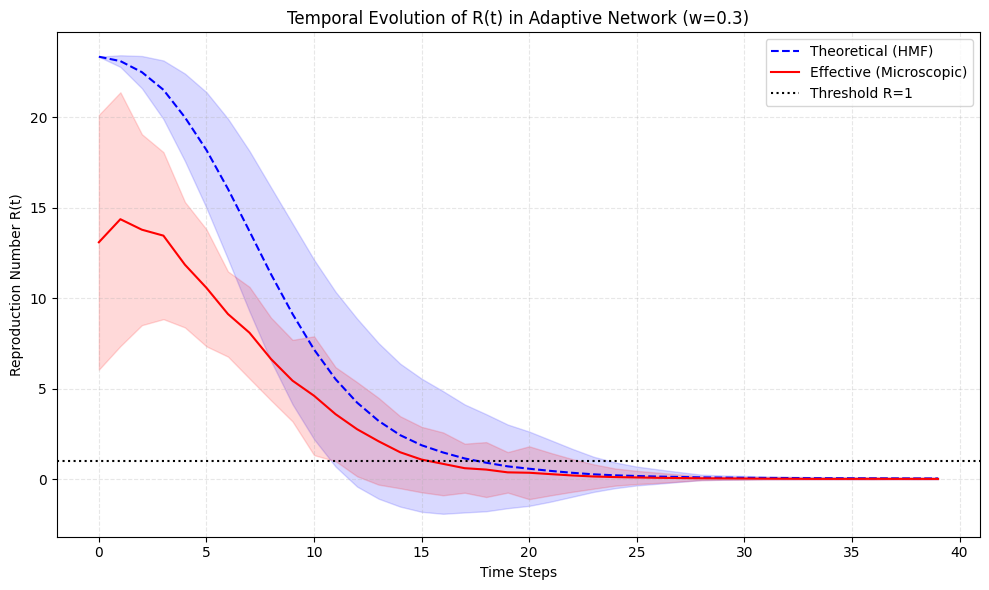

In [12]:
print("="*80)
print("MONTE CARLO SIMULATIONS TO COMPARE Rt METRIC UNDER REWIRING AGAINST A STATIC NETWORK")
print("="*80)
G_base = nx.barabasi_albert_graph(N, m)

avg_th, std_th, avg_eff, std_eff = run_monte_carlo_H5(G_base, beta=beta, gamma=gamma, w=w, steps=40, p_rand=0.2, n_sims=100)
plot_Rt_comparison_H5(avg_th, std_th, avg_eff, std_eff, w)